# 06: Daily Multi-Horizon Panel (timing prototype)

**Thin client** over `src/factors/panel_daily.py` — the prototype stage of the
roadmap's *Next Phase* (daily panel + timing models). Nothing here is
productionized yet; this notebook is the **review gate**.

**Data source:** the `prices_daily` hypertable (adjusted OHLCV, backfilled by
`scripts/backfill_prices_daily.py`) + the warehouse `fundamental_features` /
`universe` tables. Requires `POSTGRES_PASSWORD` (and `FACTOR_DB_HOST` if off-LAN).

**Design (roadmap, locked):** one daily panel, N target columns
(`target_5d / target_10d / target_30d`, within-sector ranks of the forward return
over the next *h* trading days); features shared across horizons;
fundamentals forward-filled by `availability_date` (PIT).
**For review:** the open assumptions are listed at the end.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.data import db
from src.factors import evaluate
from src.factors.panel_daily import assemble_panel_daily, ic_by_horizon

plt.style.use('seaborn-v0_8-whitegrid')
assert db.ping(), 'DB unreachable — set POSTGRES_PASSWORD (and FACTOR_DB_HOST if off-LAN)'

dcfg = load_config('features')['panel_daily']
HORIZONS, FEATURES = dcfg['horizons'], dcfg['features']
SINCE = '2019-01-01'   # output window for this review (lookbacks use full history)

p = assemble_panel_daily(since=SINCE)
print(f'panel_daily: {len(p):,} rows | {p.ticker.nunique():,} tickers | {p.date.nunique():,} days '
      f'({p.date.min():%Y-%m-%d} .. {p.date.max():%Y-%m-%d})')
print(f'daily returns masked as price errors (bounds {dcfg["return_bounds"]}): {p.attrs["returns_masked"]:,}')

panel_daily: 6,569,465 rows | 4,007 tickers | 1,947 days (2019-01-02 .. 2026-09-30)
daily returns masked as price errors (bounds [-0.9, 2.0]): 401


## Coverage — names per day, feature and target availability

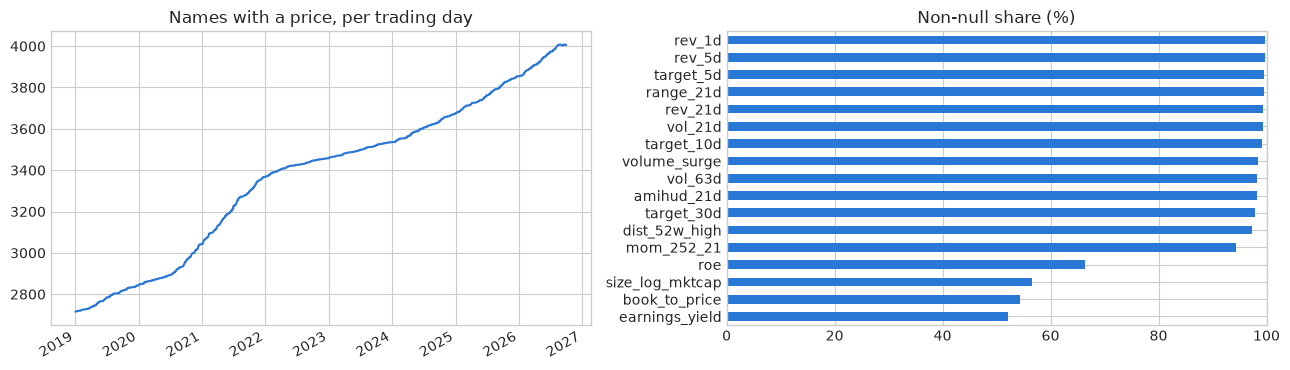

rev_1d             99.8
rev_5d             99.7
rev_21d            99.3
mom_252_21         94.3
vol_21d            99.3
vol_63d            98.3
volume_surge       98.5
amihud_21d         98.3
range_21d          99.5
dist_52w_high      97.4
size_log_mktcap    56.5
book_to_price      54.3
earnings_yield     52.2
roe                66.4
target_5d          99.5
target_10d         99.2
target_30d         97.9


In [2]:
per_day = p.groupby('date').size()
cov = (p[FEATURES + [f'target_{h}d' for h in HORIZONS]].notna().mean() * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
per_day.plot(ax=ax[0], color='#2a78d6', lw=1.5)
ax[0].set_title('Names with a price, per trading day'); ax[0].set_xlabel('')
cov.sort_values().plot.barh(ax=ax[1], color='#2a78d6')
ax[1].set_title('Non-null share (%)'); ax[1].set_xlim(0, 100)
plt.tight_layout(); plt.show()
print(cov.to_string())

## Label sanity — forward-return distribution per horizon

Masked bad prints void the labels whose window they fall in (a missing day ⇒
no label), so no artifact becomes a target. Tails should widen ~√h.

In [3]:
q = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
dist = pd.DataFrame({f'{h}d': p[f'fwd_{h}d'].quantile(q) for h in HORIZONS})
dist.index = [f'q{x:g}' for x in q]
print(dist.round(3).to_string())
print('\nmax fwd return by horizon:', {h: round(float(p[f'fwd_{h}d'].max()), 2) for h in HORIZONS})

           5d    10d    30d
q0.001 -0.475 -0.610 -0.817
q0.01  -0.230 -0.316 -0.506
q0.05  -0.117 -0.166 -0.285
q0.5    0.001  0.002  0.007
q0.95   0.123  0.177  0.325
q0.99   0.277  0.396  0.749
q0.999  0.772  1.110  2.102

max fwd return by horizon: {5: 11.61, 10: 16.42, 30: 25.11}


## Single-signal IC by horizon (non-overlapping dates)

Adjacent days' *h*-day labels share *h−1* days, so a t-stat over every day is
inflated ~√h×. `ic_by_horizon` samples every *h*-th trading day for
independent periods. (`n_months` below = number of independent periods.)

In [4]:
ic = ic_by_horizon(p, FEATURES, HORIZONS)
table = ic.pivot(index='signal', columns='horizon', values='ic_mean')[[f'{h}d' for h in HORIZONS]]
tstat = ic.pivot(index='signal', columns='horizon', values='t_stat')[[f'{h}d' for h in HORIZONS]]
print('mean IC'); print(table.round(4).sort_values(f'{HORIZONS[-1]}d').to_string())
print('\nt-stat (non-overlapping)'); print(tstat.round(1).sort_values(f'{HORIZONS[-1]}d').to_string())

mean IC
horizon              5d     10d     30d
signal                                 
range_21d       -0.0461 -0.0556 -0.0734
vol_21d         -0.0422 -0.0507 -0.0665
vol_63d         -0.0422 -0.0508 -0.0660
amihud_21d      -0.0396 -0.0455 -0.0574
rev_1d          -0.0208 -0.0224 -0.0010
rev_5d          -0.0201 -0.0072  0.0025
size_log_mktcap  0.0140  0.0123  0.0048
volume_surge    -0.0007 -0.0022  0.0053
rev_21d         -0.0067 -0.0044  0.0107
mom_252_21       0.0322  0.0339  0.0413
earnings_yield   0.0306  0.0347  0.0455
roe              0.0285  0.0340  0.0456
book_to_price    0.0269  0.0377  0.0564
dist_52w_high    0.0342  0.0400  0.0630

t-stat (non-overlapping)
horizon           5d  10d  30d
signal                        
amihud_21d      -8.6 -6.9 -5.5
range_21d       -5.2 -4.7 -3.4
vol_21d         -4.9 -4.4 -3.3
vol_63d         -4.7 -4.2 -3.0
rev_1d          -4.2 -3.2 -0.1
rev_5d          -3.6 -0.9  0.2
size_log_mktcap  2.8  1.8  0.4
rev_21d         -1.2 -0.6  0.9
volume_surge    

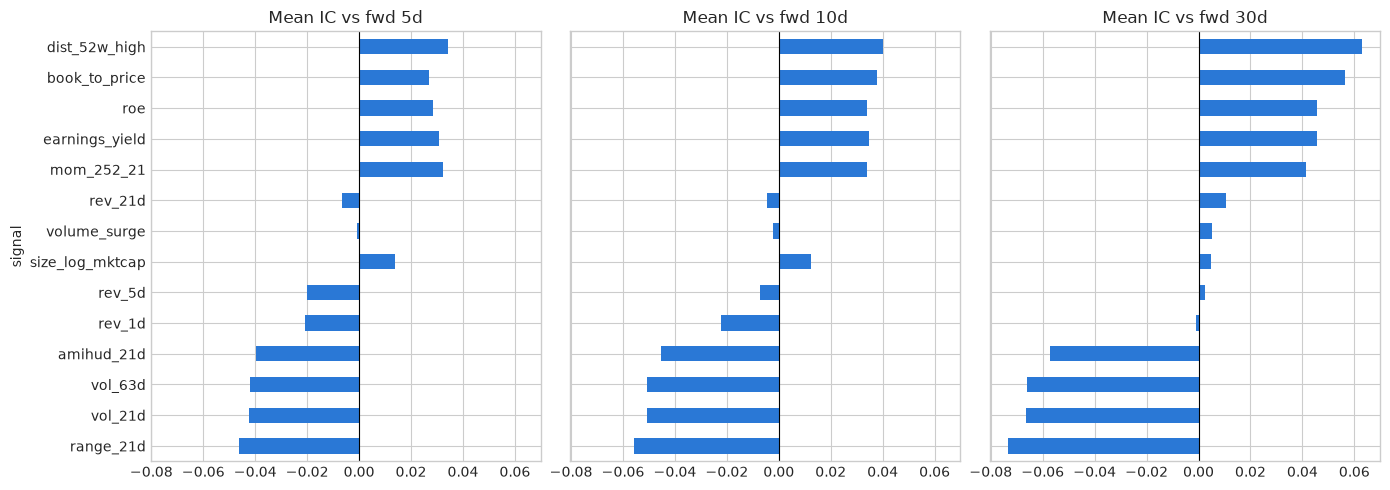

In [5]:
# IC by signal, one panel per horizon (shared x-scale so horizons compare)
order = table[f'{HORIZONS[-1]}d'].sort_values().index
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(14, 5), sharey=True, sharex=True)
for ax, h in zip(axes, HORIZONS):
    table.loc[order, f'{h}d'].plot.barh(ax=ax, color='#2a78d6')
    ax.axvline(0, color='black', lw=0.8); ax.set_title(f'Mean IC vs fwd {h}d')
plt.tight_layout(); plt.show()

## Why the overlap correction matters

Same signal, same panel: the naive every-day t-stat vs the non-overlapping one.

In [6]:
sig = table[f'{HORIZONS[-1]}d'].abs().idxmax()
for h in HORIZONS:
    naive = evaluate.ic_summary(evaluate.information_coefficient(p, sig, target=f'fwd_{h}d'))
    honest = ic[(ic.signal == sig) & (ic.horizon == f'{h}d')].iloc[0]
    print(f'{sig:>14} {h:>2}d: naive t = {naive["t_stat"]:6.1f} (n={naive["n_months"]})  |  '
          f'non-overlapping t = {honest["t_stat"]:5.1f} (n={int(honest["n_months"])})')

     range_21d  5d: naive t =  -12.4 (n=1942)  |  non-overlapping t =  -5.2 (n=389)


     range_21d 10d: naive t =  -14.9 (n=1937)  |  non-overlapping t =  -4.7 (n=194)


     range_21d 30d: naive t =  -19.5 (n=1917)  |  non-overlapping t =  -3.4 (n=64)


## Findings (first run, 2019-01 .. 2026-09)

- **Horizon separates timing from selection signals.** Short-term reversal
  (`rev_1d`, `rev_5d`) carries IC at 5d (t ≈ −4) and is gone by 30d — a timing
  signal. Value/quality/momentum/52w-high *strengthen* with horizon — selection
  signals the monthly model already uses. This is the case for a 5/10d overlay.
- **Volatility / range / Amihud are strongly negative at every horizon**
  (low-vol + liquidity). Amihud being negative (illiquid names underperform) runs
  against the classic illiquidity premium — plausibly survivorship + small-cap
  junk in a current-listings universe; worth a delisted-names check before
  trusting it.
- **Overlap correction is not cosmetic:** `range_21d` naive t = −12…−20 vs
  non-overlapping t = −3…−5 (≈ √h). Any training/eval must use the embargo and
  non-overlapping sampling.
- **Coverage:** technical features ≥ 94%; PIT fundamentals only 52–66% (names
  without an EDGAR filing in window) — the timing model should not depend on them.
- **Label tails:** max 5d forward return is still 11.6× — in-band daily moves can
  compound into an implausible label. Consider a per-window plausibility cap or
  a tighter daily band (assumption 3).

## Open assumptions — for review

1. **History depth:** `prices_daily` starts **2015-01-01** (≈10y, ~10M rows); the
   monthly panel goes back to 2000. Deeper daily history = longer backfill + table.
2. **Horizons are trading days** (5/10/30 ≈ 1w/2w/6w). The roadmap said "t+30 day";
   if calendar days were meant, 30d ≈ 21 trading days.
3. **Daily bad-print band** `[-90%, +200%]` per day (monthly panel uses
   `[-95%, +300%]` per month). A masked day voids every label window containing it.
4. **Feature set** (config `panel_daily.features`): reversal 1/5/21d, 12-1 momentum,
   21/63d vol, volume surge, Amihud illiquidity, high-low range, 52w-high distance,
   size, book-to-price, earnings yield, ROE. No intraday/bid-ask data (yfinance).
5. **Universe = today's investable set** — same survivorship caveat as the monthly
   panel, sharper here because short-horizon reversal is strongest in names that
   later delist.
6. **Next stage (after review):** walk-forward with **embargo ≥ 30 trading days**
   (the longest horizon), one LightGBM per horizon on the box, then a timing
   overlay on the monthly selection book.